In [1]:
import numpy as np
import os
import gc
import time
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    f1_score
)

import pandas as pd
import time
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau, CSVLogger

2026-05-17 21:34:13.259894: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-17 21:34:13.270376: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779028453.282899  320624 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779028453.286828  320624 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779028453.296352  320624 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [ ]:
Load_Path = "/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize64lv3/norm/dwt/"

In [3]:

train_data = np.load(os.path.join(Load_Path, "tow_ids_train_dwt.npz"))
test_data  = np.load(os.path.join(Load_Path, "tow_ids_test_dwt.npz"))
validation_data = np.load(os.path.join(Load_Path, "tow_ids_eval_dwt.npz"))

X_train = train_data["X"]
y_train = train_data["y"]

X_validation = validation_data["X"]
y_validation = validation_data["y"]

X_test  = test_data["X"]
y_test  = test_data["y"]

print(X_train.shape, y_train.shape)
print(X_validation.shape, y_validation.shape)
print(X_test.shape, y_test.shape)


(3291, 32, 32, 3) (3291,)
(1410, 32, 32, 3) (1410,)
(3092, 32, 32, 3) (3092,)


In [4]:
print("Train label distribution:", np.unique(y_train, return_counts=True))
print("Test label distribution :", np.unique(y_test, return_counts=True))
print("Validation label distribution :", np.unique(y_validation, return_counts=True))

print("Min value:", X_train.min())
print("Max value:", X_train.max())


Train label distribution: (array([0, 1]), array([1524, 1767]))
Test label distribution : (array([0, 1]), array([1600, 1492]))
Validation label distribution : (array([0, 1]), array([ 382, 1028]))
Min value: -0.8601289
Max value: 8.30175


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models


def composite_conv(x, filters, kernel_size):
    x = layers.Conv2D(
        filters,
        kernel_size,
        padding="same",
        use_bias=False
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.ReLU()(x)

    return x


def SE_block(x, ratio=8):
    channels = x.shape[-1]

    se = layers.GlobalAveragePooling2D()(x)

    se = layers.Dense(
        channels // ratio,
        activation="relu"
    )(se)

    se = layers.Dense(
        channels,
        activation="sigmoid"
    )(se)

    se = layers.Reshape((1, 1, channels))(se)

    out = layers.Multiply()([x, se])

    return out


def DPDB_block(x, filters, pool=True):
    shortcut = x

    h = composite_conv(x, filters // 2, (1, 3))

    v = composite_conv(x, filters // 2, (3, 1))

    concat = layers.Concatenate()([h, v])

    fusion = composite_conv(concat, filters, (1, 1))

    fusion = SE_block(fusion)

    if pool:
        fusion = layers.MaxPooling2D((2, 2))(fusion)

    shortcut = layers.Conv2D(
        filters,
        (1, 1),
        padding="same",
        use_bias=False
    )(shortcut)

    shortcut = layers.BatchNormalization()(shortcut)

    if pool:
        shortcut = layers.MaxPooling2D((2, 2))(shortcut)

    out = layers.Add()([fusion, shortcut])

    out = layers.ReLU()(out)

    return out


input_layer = layers.Input(shape=(8, 8, 3))

x = composite_conv(input_layer, 16, (1, 3))

x = composite_conv(x, 16, (3, 1))

x = DPDB_block(x, 32, pool=True)

x = DPDB_block(x, 64, pool=False)

x = composite_conv(x, 64, (1, 1))

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(
    128,
    activation="relu"
)(x)

x = layers.Dropout(0.2)(x)

output_layer = layers.Dense(
    1,
    activation="sigmoid"
)(x)

model = models.Model(
    inputs=input_layer,
    outputs=output_layer
)

model.summary()

I0000 00:00:1779028454.566800  320624 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1173 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        144 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │        768 │ re_lu[0][0]       │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │        768 │ re_lu_1[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │        768 │ re_lu_1[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ re_lu_2[0][0],    │
│ (Concatenate)       │ 32)               │            │ re_lu_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │      1,024 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat

 Total params: 31,741 (123.99 KB)

 Trainable params: 30,973 (120.99 KB)

 Non-trainable params: 768 (3.00 KB)

In [6]:
model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]
)

In [7]:
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

tf.debugging.set_log_device_placement(True)

TensorFlow version: 2.19.1
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:
class TrainingLogger(Callback):

    def on_train_begin(self, logs=None):
        print("\nTraining started")
        print("-"*70)
        print("{:<8} {:<12} {:<12} {:<12} {:<12}".format(
            "Epoch","Loss","Accuracy","Val_Loss","Val_Acc"))
        print("-"*70)

    def on_epoch_end(self, epoch, logs=None):

        print("{:<8} {:<12.4f} {:<12.4f} {:<12.4f} {:<12.4f}".format(
            epoch+1,
            logs["loss"],
            logs["accuracy"],
            logs["val_loss"],
            logs["val_accuracy"]
        ))

In [9]:
checkpoint = ModelCheckpoint(
    "best_model_tow_idsIMGSIZE64.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=0
)

In [10]:
print("\nDataset summary")
print("-"*40)
print("Train samples :", X_train.shape[0])
print("Test samples  :", X_test.shape[0])
print("Validation samples  :", X_validation.shape[0])
print("Image shape   :", X_train.shape[1:])
print("Batch size    :", 16)
print("Epochs        :", 100)
print("-"*40)


Dataset summary
----------------------------------------
Train samples : 3291
Test samples  : 3092
Validation samples  : 1410
Image shape   : (32, 32, 3)
Batch size    : 16
Epochs        : 100
----------------------------------------


In [11]:
with tf.device('/CPU:0'):
    train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
    test_dataset  = tf.data.Dataset.from_tensor_slices((X_test, y_test))
    validation_dataset  = tf.data.Dataset.from_tensor_slices((X_validation, y_validation))

train_dataset = (
    train_dataset
    .shuffle(1000)
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)
validation_dataset = (
    validation_dataset
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    test_dataset
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)

In [12]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=100,
    verbose=1,
    callbacks=[checkpoint]
)

Epoch 1/100


I0000 00:00:1779028458.509127  320754 service.cc:152] XLA service 0x7f2b000022a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779028458.509149  320754 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2026-05-17 21:34:18.606420: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779028459.300982  320754 cuda_dnn.cc:529] Loaded cuDNN version 91701


 46/206 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8571 - loss: 0.4870

I0000 00:00:1779028464.954144  320754 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


198/206 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9194 - loss: 0.2876

2026-05-17 21:34:27.256488: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3261', 8 bytes spill stores, 8 bytes spill loads



206/206 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9206 - loss: 0.2833

2026-05-17 21:34:33.253186: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_373', 8 bytes spill stores, 8 bytes spill loads



206/206 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.9496 - loss: 0.1739 - val_accuracy: 0.7291 - val_loss: 1.0119
Epoch 2/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9769 - loss: 0.0679 - val_accuracy: 0.9773 - val_loss: 0.0716
Epoch 3/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9790 - loss: 0.0618 - val_accuracy: 0.9773 - val_loss: 0.0956
Epoch 4/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9851 - loss: 0.0511 - val_accuracy: 0.9801 - val_loss: 0.0775
Epoch 5/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9830 - loss: 0.0515 - val_accuracy: 0.9830 - val_loss: 0.0758
Epoch 6/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9830 - loss: 0.0506 - val_accuracy: 0.9844 - val_loss: 0.0640
Epoch 7/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9888 - loss: 0.0390 - val_accuracy: 0.9837 - val_loss: 0.0736
Epoch 8/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9903 - loss: 0.0402 - val_accuracy: 0.98

In [13]:
# =========================
# CELL 1
# =========================

import numpy as np
from sklearn.metrics import roc_curve

# prediksi probabilitas
y_prob = model.predict(test_dataset).ravel()

# label asli
y_true = y_test

# =========================
# EVALUASI DEFAULT THRESHOLD 0.5
# =========================

default_threshold = 0.5
y_pred_default = (y_prob >= default_threshold).astype(int)

# =========================
# CARI THRESHOLD TERBAIK
# =========================
# strategi:
# cari threshold dengan F1 tertinggi

thresholds = np.arange(0.1, 0.91, 0.01)

best_threshold = 0.5
best_f1 = 0

for th in thresholds:

    y_pred_temp = (y_prob >= th).astype(int)

    TP = np.sum((y_true == 1) & (y_pred_temp == 1))
    TN = np.sum((y_true == 0) & (y_pred_temp == 0))
    FP = np.sum((y_true == 0) & (y_pred_temp == 1))
    FN = np.sum((y_true == 1) & (y_pred_temp == 0))

    precision = TP / (TP + FP + 1e-12)
    recall = TP / (TP + FN + 1e-12)

    f1 = 2 * precision * recall / (precision + recall + 1e-12)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = th

print("Best Threshold:", best_threshold)
print("Best F1 Score :", best_f1)

# prediksi final threshold terbaik
y_pred_best = (y_prob >= best_threshold).astype(int)

158/194 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

2026-05-17 21:35:59.427990: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_364', 8 bytes spill stores, 8 bytes spill loads



194/194 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step
Best Threshold: 0.8999999999999996
Best F1 Score : 0.9750328515106692


In [14]:
# =========================
# CELL 2
# =========================

from sklearn.metrics import confusion_matrix

# ===== DEFAULT 0.5 =====
cm_default = confusion_matrix(y_true, y_pred_default)

TN_d, FP_d, FN_d, TP_d = cm_default.ravel()

print("=== Confusion Matrix (Threshold = 0.5) ===")
print(cm_default)

# ===== BEST THRESHOLD =====
cm_best = confusion_matrix(y_true, y_pred_best)

TN_b, FP_b, FN_b, TP_b = cm_best.ravel()

print("\n=== Confusion Matrix (Best Threshold) ===")
print(cm_best)

=== Confusion Matrix (Threshold = 0.5) ===
[[1486  114]
 [   4 1488]]

=== Confusion Matrix (Best Threshold) ===
[[1532   68]
 [   8 1484]]


In [15]:
# =========================
# CELL 3
# =========================

def calculate_metrics(TN, FP, FN, TP):

    accuracy = (TP + TN) / (TP + TN + FP + FN)

    precision = TP / (TP + FP + 1e-12)

    recall = TP / (TP + FN + 1e-12)

    f1 = 2 * precision * recall / (precision + recall + 1e-12)

    FPR = FP / (FP + TN + 1e-12)

    FNR = FN / (FN + TP + 1e-12)

    return accuracy, precision, recall, f1, FPR, FNR


# ===== DEFAULT =====
metrics_default = calculate_metrics(TN_d, FP_d, FN_d, TP_d)

# ===== BEST =====
metrics_best = calculate_metrics(TN_b, FP_b, FN_b, TP_b)

In [16]:
# =========================
# CELL 4
# =========================

metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "FPR",
    "FNR"
]

print("========================================")
print("THRESHOLD = 0.5")
print("========================================")

for name, value in zip(metric_names, metrics_default):
    print(f"{name:10}: {value:.6f}")

print("\n")

print("========================================")
print(f"BEST THRESHOLD = {best_threshold:.2f}")
print("========================================")

for name, value in zip(metric_names, metrics_best):
    print(f"{name:10}: {value:.6f}")

THRESHOLD = 0.5
Accuracy  : 0.961837
Precision : 0.928839
Recall    : 0.997319
F1-score  : 0.961862
FPR       : 0.071250
FNR       : 0.002681


BEST THRESHOLD = 0.90
Accuracy  : 0.975420
Precision : 0.956186
Recall    : 0.994638
F1-score  : 0.975033
FPR       : 0.042500
FNR       : 0.005362


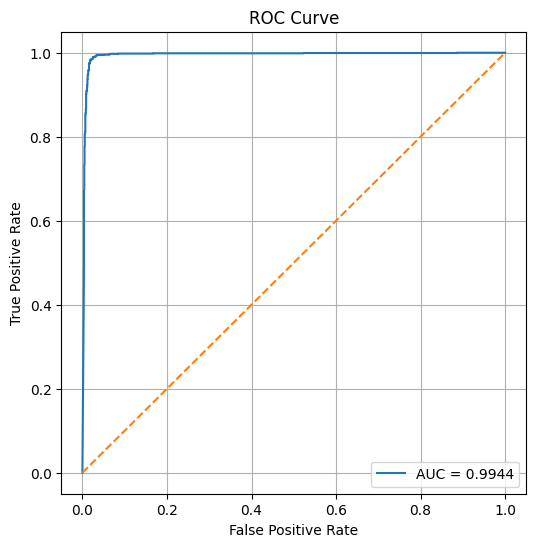

In [17]:
# =========================
# CELL 5
# =========================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label="AUC = %0.4f" % roc_auc)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()